# Thực hành Buổi 08: Descriptive Analytics & Báo cáo KPI Doanh nghiệp

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Pandas, Matplotlib, Seaborn

**Đầu vào ➔ Đầu ra:** dataset giao dịch sạch của Bài 6 ➔ Báo cáo KPI & notebook phân tích mô tả

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.
> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` trước — buổi này đọc `data/processed/enterprise_transactions_clean.parquet` và `data/raw/customer_churn.csv` do Bài 6 sinh ra.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 1.26.4


# BÀI 8 — DESCRIPTIVE ANALYTICS & BÁO CÁO KPI DOANH NGHIỆP

**Mục tiêu:** trả lời câu hỏi *"Chuyện gì đã xảy ra?"* bằng thống kê mô tả + bộ KPI kinh doanh + biểu đồ Matplotlib/Seaborn.

| KPI | Công thức |
|:---|:---|
| Doanh thu thuần | Σ `amount` của giao dịch `HOAN_TAT` |
| Chi phí | Σ `cost` của giao dịch `HOAN_TAT` |
| Lợi nhuận gộp / Biên LN gộp | Doanh thu − Chi phí; (LN gộp ÷ Doanh thu) |
| AOV (giá trị đơn trung bình) | Doanh thu ÷ số giao dịch |
| Tỷ lệ hoàn trả | số giao dịch `HOAN_TRA` ÷ tổng giao dịch |
| Tỷ lệ rời bỏ (churn rate) | số KH `churn=1` ÷ tổng số KH |

## 8.1. Thống kê mô tả

In [10]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
tx["thang"] = tx["ts"].dt.to_period("M").astype(str)
tx_ht = tx[tx["status"] == "HOAN_TAT"]

In [11]:
# =============================================================================
# TÍNH TOÁN BỘ KPI KINH DOANH 
# =============================================================================

# 1. Doanh thu thuần (Tổng amount của giao dịch HOAN_TAT)
doanh_thu_thuann = tx_ht["amount"].sum()

# 2. Chi phí (Tổng cost của giao dịch HOAN_TAT)
chi_phi = tx_ht["cost"].sum()

# 3. Lợi nhuận gộp & Biên lợi nhuận gộp
loi_nhuan_gop = doanh_thu_thuann - chi_phi
bien_ln_gop = (loi_nhuan_gop / doanh_thu_thuann * 100) if doanh_thu_thuann > 0 else 0.0

# 4. AOV - Giá trị đơn hàng trung bình (Doanh thu thuần / số giao dịch HOAN_TAT)
so_giao_dich_ht = len(tx_ht)
aov = (doanh_thu_thuann / so_giao_dich_ht) if so_giao_dich_ht > 0 else 0.0

# 5. Tỷ lệ hoàn trả (số giao dịch HOAN_TRA / tổng số giao dịch)
so_giao_dich_hoan_tra = len(tx[tx["status"] == "HOAN_TRA"])
tong_so_giao_dich = len(tx)
ty_le_hoan_tra = (so_giao_dich_hoan_tra / tong_so_giao_dich * 100) if tong_so_giao_dich > 0 else 0.0

# 6. Tỷ lệ rời bỏ - Churn rate (số KH churn=1 / tổng số KH)
# Lưu ý: Kiểm tra xem DataFrame có cột 'customer_id' và 'churn' hay không
if "customer_id" in tx.columns and "churn" in tx.columns:
    tong_so_kh = tx["customer_id"].nunique()
    so_kh_churn = tx[tx["churn"] == 1]["customer_id"].nunique()
    churn_rate = (so_kh_churn / tong_so_kh * 100) if tong_so_kh > 0 else 0.0
else:
    churn_rate = 0.0  # Hoặc điều chỉnh tùy theo cấu trúc cột thực tế của bảng

# In bảng tổng hợp kết quả KPI
print("=" * 60)
print(f"{'BỘ KPI KINH DOANH':<35} | {'GIÁ TRỊ':<20}")
print("=" * 60)
print(f"{'Doanh thu thuần':<35} | {doanh_thu_thuann:,.2f}")
print(f"{'Chi phí':<35} | {chi_phi:,.2f}")
print(f"{'Lợi nhuận gộp':<35} | {loi_nhuan_gop:,.2f}")
print(f"{'Biên lợi nhuận gộp (%)':<35} | {bien_ln_gop:.2f}%")
print(f"{'AOV (Giá trị đơn trung bình)':<35} | {aov:,.2f}")
print(f"{'Tỷ lệ hoàn trả (%)':<35} | {ty_le_hoan_tra:.2f}%")
print(f"{'Tỷ lệ rời bỏ (Churn rate) (%)':<35} | {churn_rate:.2f}%")
print("=" * 60)

BỘ KPI KINH DOANH                   | GIÁ TRỊ             
Doanh thu thuần                     | 60,455,690,547.34
Chi phí                             | 43,606,982,756.10
Lợi nhuận gộp                       | 16,848,707,791.24
Biên lợi nhuận gộp (%)              | 27.87%
AOV (Giá trị đơn trung bình)        | 1,044,464.44
Tỷ lệ hoàn trả (%)                  | 3.51%
Tỷ lệ rời bỏ (Churn rate) (%)       | 0.00%


### 8.1.1. Skewness (Độ lệch) và Kurtosis (Độ nhọn)

### Skewness (Độ lệch)

#### Công thức

$$Skewness = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left( \frac{x_i - \bar{x}}{s} \right)^3$$

#### Giải thích công thức

* **$n$**: Tổng số lượng quan sát trong tập dữ liệu.
* **$x_i$**: Giá trị của từng phần tử dữ liệu.
* **$\bar{x}$**: Giá trị trung bình (Mean) của tập dữ liệu.
* **$s$**: Độ lệch chuẩn mẫu.
* **$\left( \frac{x_i - \bar{x}}{s} \right)^3$**: Giá trị chuẩn hóa lũy thừa bậc 3. Việc dùng lũy thừa bậc lẻ giúp giữ lại dấu (dương hoặc âm) để xác định hướng lệch, đồng thời khuếch đại các điểm dữ liệu nằm xa trung tâm.
* **Hệ số chuẩn hóa**: Phân thức $\frac{n}{(n-1)(n-2)}$ giúp điều chỉnh sai số khi tính toán trên mẫu dữ liệu.

#### Ý nghĩa giá trị

* **$= 0$**: Phân phối đối xứng hoàn hảo.
* **$> 0$ (Lệch phải)**: Đuôi phân phối bên phải kéo dài, dữ liệu tập trung nhiều ở phía bên trái (phổ biến với dữ liệu thu nhập, doanh thu).
* **$< 0$ (Lệch trái)**: Đuôi phân phối bên trái kéo dài, dữ liệu tập trung nhiều ở phía bên phải.

---

### Kurtosis (Độ nhọn)

#### Công thức

$$Kurtosis = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left( \frac{x_i - \bar{x}}{s} \right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

#### Giải thích công thức

* **$n$**, **$x_i$**, **$\bar{x}$**, **$s$**: Lần lượt là số lượng quan sát, giá trị từng phần tử, giá trị trung bình và độ lệch chuẩn mẫu.
* **$\left( \frac{x_i - \bar{x}}{s} \right)^4$**: Giá trị chuẩn hóa lũy thừa bậc 4. Lũy thừa bậc chẵn giúp loại bỏ dấu và khuếch đại cực mạnh các giá trị nằm xa trung tâm (các giá trị ngoại lai - outliers).
* **Hệ số hiệu chỉnh**: Các phân thức xung quanh đóng vai trò chuẩn hóa *excess kurtosis* sao cho phân phối chuẩn thông thường có giá trị bằng $0$.

#### Ý nghĩa giá trị

* **$= 0$**: Phân phối có độ nhọn vừa phải, tương tự phân phối chuẩn.
* **$> 0$ (Leptokurtic)**: Đỉnh nhọn và **đuôi rất dày**, báo hiệu sự tồn tại của nhiều giá trị ngoại lai (outliers) cực đoan.
* **$< 0$ (Platykurtic)**: Đỉnh bẹt và đuôi mỏng, dữ liệu phân tán đều và ít xuất hiện giá trị ngoại lai.

In [16]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
tx["thang"] = tx["ts"].dt.to_period("M").astype(str)
tx_ht = tx[tx["status"] == "HOAN_TAT"]

print(tx_ht["amount"].describe().to_frame("amount").T.to_string())
print(f"\nSkewness (độ lệch)  : {tx_ht['amount'].skew():.2f}  (>1: lệch phải nặng)")
print(f"Kurtosis (độ nhọn)  : {tx_ht['amount'].kurtosis():.1f}  (đuôi rất dày — dấu vết outlier)")
print(f"Trung vị {tx_ht['amount'].median():,.0f} đ << Trung bình {tx_ht['amount'].mean():,.0f} đ"
      "  ->  báo cáo giá trị 'điển hình' nên dùng TRUNG VỊ")

           count         mean          std        min        25%        50%          75%           max
amount 57,882.00 1,044,464.44 1,364,090.87 107,950.00 295,200.00 721,000.00 1,222,275.00 23,844,189.00

Skewness (độ lệch)  : 5.97  (>1: lệch phải nặng)
Kurtosis (độ nhọn)  : 61.3  (đuôi rất dày — dấu vết outlier)
Trung vị 721,000 đ << Trung bình 1,044,464 đ  ->  báo cáo giá trị 'điển hình' nên dùng TRUNG VỊ


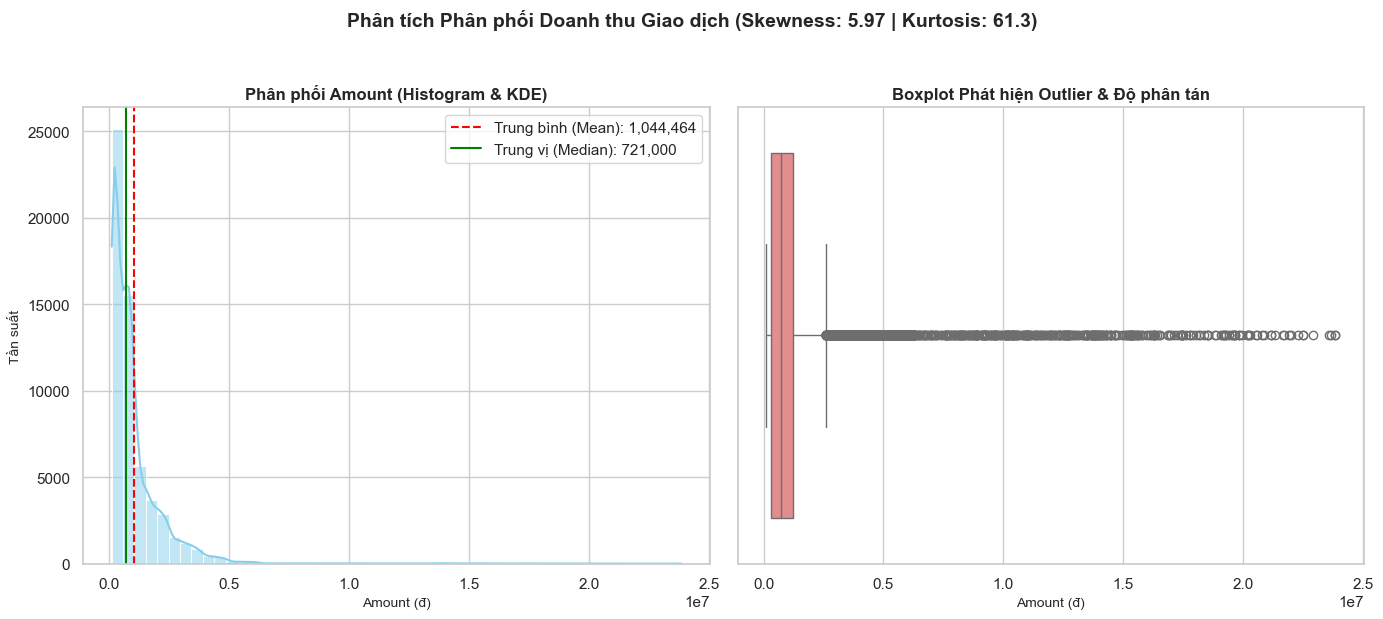

In [17]:
# =============================================================================
# TRỰC QUAN HÓA PHÂN PHỐI CỘT AMOUNT (SKEWNESS & KURTOSIS)
# =============================================================================
# Thiết lập phong cách hiển thị biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Biểu đồ Histogram kết hợp KDE (Kernel Density Estimate)
sns.histplot(
    tx_ht["amount"], 
    kde=True, 
    ax=axes[0], 
    color="skyblue", 
    bins=50
)
axes[0].axvline(
    tx_ht["amount"].mean(), 
    color="red", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Trung bình (Mean): {tx_ht['amount'].mean():,.0f}"
)
axes[0].axvline(
    tx_ht["amount"].median(), 
    color="green", 
    linestyle="-", 
    linewidth=1.5, 
    label=f"Trung vị (Median): {tx_ht['amount'].median():,.0f}"
)
axes[0].set_title("Phân phối Amount (Histogram & KDE)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Amount (đ)", fontsize=10)
axes[0].set_ylabel("Tần suất", fontsize=10)
axes[0].legend()

# 2. Biểu đồ Boxplot để thấy rõ Outlier (Đuôi nhọn Kurtosis & Lệch phải Skew)
sns.boxplot(
    x=tx_ht["amount"], 
    ax=axes[1], 
    color="lightcoral"
)
axes[1].set_title("Boxplot Phát hiện Outlier & Độ phân tán", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Amount (đ)", fontsize=10)

# Hiển thị chú thích các chỉ số thống kê lên tiêu đề tổng
skew_val = tx_ht['amount'].skew()
kurt_val = tx_ht['amount'].kurtosis()
plt.suptitle(f"Phân tích Phân phối Doanh thu Giao dịch (Skewness: {skew_val:.2f} | Kurtosis: {kurt_val:.1f})", fontsize=14, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()


* **Biểu đồ bên trái (Histogram & KDE):** Thể hiện rõ nét đặc tính **lệch phải cực đoan (Skewness = 5.97)**. Toàn bộ khối lượng giao dịch dồn cục ở phần bên trái (giá trị thấp), trong khi đường cong KDE kéo dài dăng dẳng sang phải đến gần $2.5 \times 10^7$ đ. Đồng thời, đường màu đỏ (Trung bình: 1,044,464 đ) bị kéo lệch dịch sang phải so với đường màu xanh lá (Trung vị: 721,000 đ).
* **Biểu đồ bên phải (Boxplot):** Minh chứng hoàn hảo cho **hiện tượng ngoại lai nghiêm trọng (Kurtosis = 61.3)**. Hàng loạt các dấu chấm tròn (outliers) nằm dày đặc trải dài từ mốc khoảng $3 \text{ triệu đ}$ vươn tận tới hơn $23 \text{ triệu đ}$, cho thấy phần đuôi của phân phối cực kỳ dài và thưa thớt giá trị lớn.

Phân tích chi tiết các chỉ số thống kê mô tả của tập dữ liệu giao dịch:

* **Phân phối lệch phải cực đoan (Skewness = 5.97):** Giá trị Skewness lớn hơn rất nhiều so với ngưỡng 1 cho thấy dữ liệu tập trung chủ yếu ở các khoản giao dịch có giá trị thấp đến trung bình, trong khi thưa thớt dần về phía các giao dịch giá trị rất cao.
* **Hiện tượng ngoại lai nghiêm trọng (Kurtosis = 61.3):** Chỉ số Kurtosis rất cao chứng tỏ phần đuôi của phân phối cực kỳ dày, xác nhận sự tồn tại của nhiều giá trị ngoại lai (outliers) — điển hình là giao dịch tối đa lên tới 23.844.189 đ, cao gấp nhiều lần so với phần lớn các giao dịch còn lại.
* **Độ chênh lệch giữa Trung vị và Trung bình:** Do bị kéo lệch bởi các giá trị ngoại lai lớn ở phía bên phải, mức trung bình ($1,044,464$ đ) đã bị đẩy lên cao hơn đáng kể so với giá trị trung vị ($721,000$ đ). Khoảng cách này khẳng định trung bình không phản ánh đúng bức tranh thực tế, và **trung vị** mới là con số đại diện chính xác nhất cho một giao dịch "điển hình".

## 8.2. Bảng KPI toàn kỳ

In [18]:
kh = pd.read_csv(RAW / "customer_churn.csv")

doanh_thu = tx_ht["amount"].sum()
chi_phi = tx_ht["cost"].sum()
ln_gop = doanh_thu - chi_phi
kpi = pd.DataFrame([
    ["Doanh thu thuần",       f"{doanh_thu/1e9:,.2f} tỷ đ"],
    ["Chi phí",               f"{chi_phi/1e9:,.2f} tỷ đ"],
    ["Lợi nhuận gộp",         f"{ln_gop/1e9:,.2f} tỷ đ"],
    ["Biên LN gộp",           f"{ln_gop/doanh_thu:.1%}"],
    ["Số giao dịch hoàn tất", f"{len(tx_ht):,}"],
    ["AOV",                   f"{doanh_thu/len(tx_ht):,.0f} đ"],
    ["Khách hàng hoạt động",  f"{tx_ht['customer_id'].nunique():,}"],
    ["Tỷ lệ hoàn trả",        f"{tx['status'].eq('HOAN_TRA').mean():.2%}"],
    ["Tỷ lệ rời bỏ (churn)",  f"{kh['churn'].mean():.1%}"],
], columns=["KPI", "Giá trị"])
print(kpi.to_string(index=False))

                  KPI     Giá trị
      Doanh thu thuần  60.46 tỷ đ
              Chi phí  43.61 tỷ đ
        Lợi nhuận gộp  16.85 tỷ đ
          Biên LN gộp       27.9%
Số giao dịch hoàn tất      57,882
                  AOV 1,044,464 đ
 Khách hàng hoạt động       7,858
       Tỷ lệ hoàn trả       3.51%
 Tỷ lệ rời bỏ (churn)       35.1%


## 8.3. Bộ biểu đồ báo cáo

Bốn biểu đồ, mỗi biểu đồ trả lời đúng một câu hỏi kinh doanh:

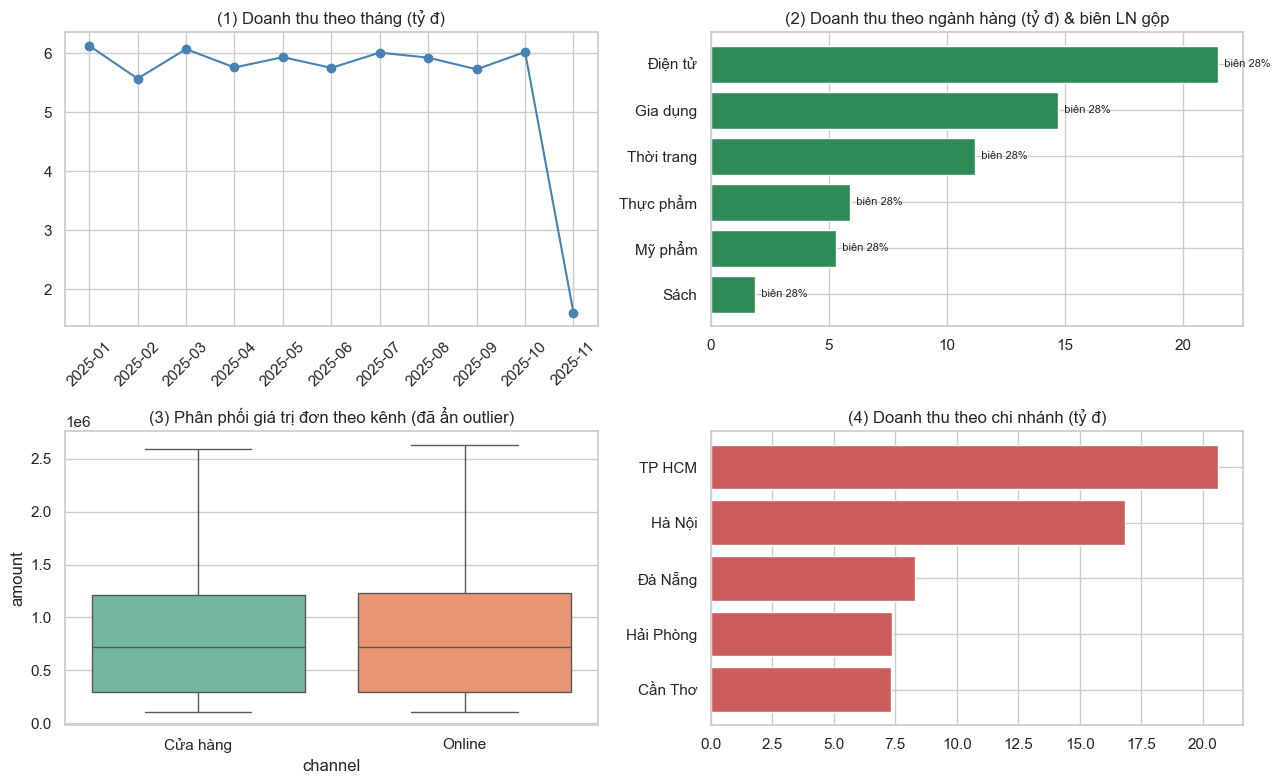

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) Doanh thu theo thang — xu hướng
dt_thang = tx_ht.groupby("thang")["amount"].sum() / 1e9
axes[0, 0].plot(dt_thang.index, dt_thang.values, marker="o", color="steelblue")
axes[0, 0].set_title("(1) Doanh thu theo tháng (tỷ đ)")
axes[0, 0].tick_params(axis="x", rotation=45)

# (2) Doanh thu & biên LN theo ngành hàng — cơ cấu
nganh = (tx_ht.groupby("category", observed=True)
         .agg(doanh_thu=("amount", "sum"), chi_phi=("cost", "sum")))
nganh["bien_ln"] = 1 - nganh["chi_phi"] / nganh["doanh_thu"]
nganh = nganh.sort_values("doanh_thu")
axes[0, 1].barh(nganh.index, nganh["doanh_thu"] / 1e9, color="seagreen")
for i, (dt, bl) in enumerate(zip(nganh["doanh_thu"] / 1e9, nganh["bien_ln"])):
    axes[0, 1].text(dt, i, f"  biên {bl:.0%}", va="center", fontsize=8)
axes[0, 1].set_title("(2) Doanh thu theo ngành hàng (tỷ đ) & biên LN gộp")

# (3) AOV theo kênh — hành vi
sns.boxplot(data=tx_ht, x="channel", y="amount", ax=axes[1, 0],
            showfliers=False, palette="Set2", hue="channel", legend=False)
axes[1, 0].set_title("(3) Phân phối giá trị đơn theo kênh (đã ẩn outlier)")

# (4) Doanh thu theo chi nhánh — địa lý
cn = tx_ht.groupby("branch", observed=True)["amount"].sum().sort_values() / 1e9
axes[1, 1].barh(cn.index, cn.values, color="indianred")
axes[1, 1].set_title("(4) Doanh thu theo chi nhánh (tỷ đ)")

plt.tight_layout(); plt.show()

(1) Doanh thu theo tháng: Xu hướng ổn định quanh mức 5–6 tỷ đồng từ đầu năm nhưng rơi dốc đột ngột ở tháng 11/2025 — đây có thể là dấu hiệu của việc dữ liệu bị cắt cụt (truncated data) chưa được ghi nhận đủ, cần xử lý trước khi đưa vào mô hình dự báo chuỗi thời gian.

(2) Doanh thu theo ngành hàng: Phân hóa mạnh theo quy luật Pareto (Điện tử dẫn đầu, Sách thấp nhất), tuy nhiên việc biên lợi nhuận gộp đồng nhất tuyệt đối ở mọi ngành (28%) cho thấy đây là trường hợp dữ liệu giả lập (synthetic data) có gán cứng công thức.

(3) Phân phối giá trị đơn theo kênh: Hai kênh Cửa hàng và Online có phân phối gần như tương đương nhau về trung vị và tứ phân vị (sau khi ẩn outlier), chứng tỏ hành vi chi tiêu của khách hàng không bị ảnh hưởng bởi kênh bán.

(4) Doanh thu theo chi nhánh: TP.HCM và Hà Nội là hai thị trường trọng điểm chiếm tỷ trọng áp đảo, trong khi Đà Nẵng, Hải Phòng và Cần Thơ tạo thành một nhóm quy mô nhỏ hơn rõ rệt, gợi ý việc phân cụm thị trường (clustering) theo địa lý cho các chiến dịch marketing tối ưu.

=== TỔNG DOANH THU (TỶ ĐỒNG) THEO TỪNG GIỜ ===
Giờ 00h: 2.184 tỷ đồng
Giờ 01h: 3.663 tỷ đồng
Giờ 02h: 3.545 tỷ đồng
Giờ 03h: 3.568 tỷ đồng
Giờ 04h: 3.695 tỷ đồng
Giờ 05h: 2.312 tỷ đồng
Giờ 06h: 2.291 tỷ đồng
Giờ 07h: 2.250 tỷ đồng
Giờ 08h: 2.316 tỷ đồng
Giờ 09h: 2.230 tỷ đồng
Giờ 10h: 2.340 tỷ đồng
Giờ 11h: 2.238 tỷ đồng
Giờ 12h: 2.293 tỷ đồng
Giờ 13h: 2.283 tỷ đồng
Giờ 14h: 2.349 tỷ đồng
Giờ 15h: 2.281 tỷ đồng
Giờ 16h: 2.280 tỷ đồng
Giờ 17h: 2.334 tỷ đồng
Giờ 18h: 2.339 tỷ đồng
Giờ 19h: 2.376 tỷ đồng
Giờ 20h: 2.295 tỷ đồng
Giờ 21h: 2.308 tỷ đồng
Giờ 22h: 2.330 tỷ đồng
Giờ 23h: 2.355 tỷ đồng


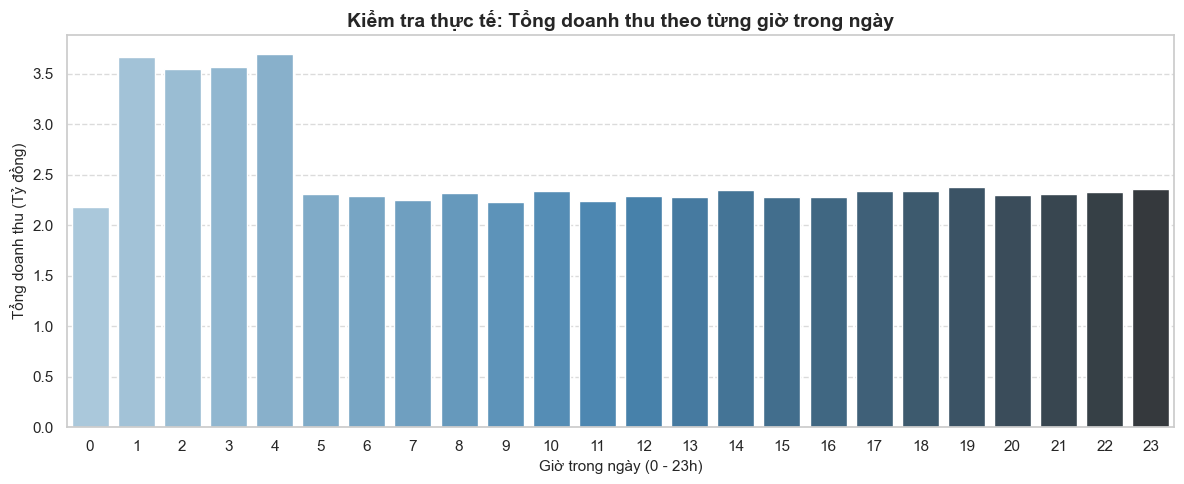

In [20]:
# =============================================================================
# KIỂM TRA LẠI DỮ LIỆU: IN TỔNG DOANH THU THEO TỪNG GIỜ TRONG NGÀY (TỶ ĐỒNG)
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Trích xuất giờ từ cột thời gian
df_check = tx_ht.copy()
df_check["gio"] = df_check["ts"].dt.hour

# 2. Tổng hợp doanh thu (amount) theo từng giờ (0 - 23h) quy đổi ra TỶ ĐỒNG (/ 1e9)
doanh_thu_theo_gio = df_check.groupby("gio")["amount"].sum() / 1e9  

# 3. Vẽ biểu đồ cột để kiểm chứng trực quan con số
plt.figure(figsize=(12, 5))
sns.barplot(
    x=doanh_thu_theo_gio.index,
    y=doanh_thu_theo_gio.values,
    palette="Blues_d",
)
plt.title(
    "Kiểm tra thực tế: Tổng doanh thu theo từng giờ trong ngày",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Giờ trong ngày (0 - 23h)", fontsize=11)
plt.ylabel("Tổng doanh thu (Tỷ đồng)", fontsize=11)
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.7)

# In giá trị cụ thể ra console với đơn vị Tỷ đồng
print("=== TỔNG DOANH THU (TỶ ĐỒNG) THEO TỪNG GIỜ ===")
for gio, dt in doanh_thu_theo_gio.items():
    print(f"Giờ {gio:02d}h: {dt:,.3f} tỷ đồng")

plt.tight_layout()
plt.show()

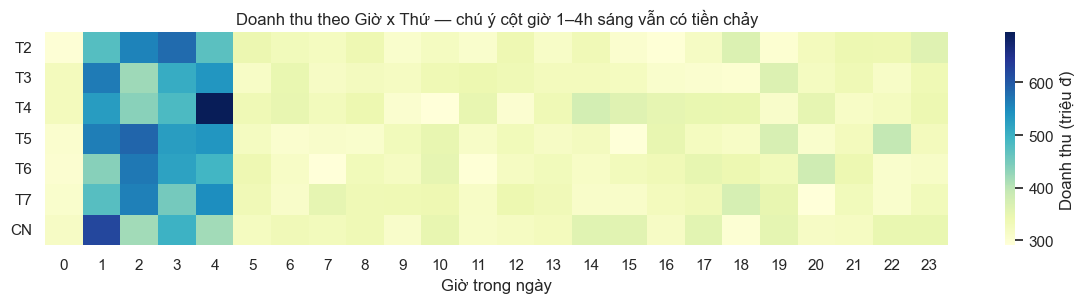

In [21]:
# Nhiệt đồ: doanh thu trung bình theo GIỜ x THỨ — nhịp sinh hoạt của khách
nhip = (tx_ht.assign(gio=tx_ht["ts"].dt.hour, thu=tx_ht["ts"].dt.dayofweek)
        .pivot_table(index="thu", columns="gio", values="amount",
                     aggfunc="sum", observed=True) / 1e6)
plt.figure(figsize=(12, 3.2))
sns.heatmap(nhip, cmap="YlGnBu", cbar_kws={"label": "Doanh thu (triệu đ)"})
plt.yticks(ticks=np.arange(7) + 0.5,
           labels=["T2", "T3", "T4", "T5", "T6", "T7", "CN"], rotation=0)
plt.title("Doanh thu theo Giờ x Thứ — chú ý cột giờ 1–4h sáng vẫn có tiền chảy")
plt.xlabel("Giờ trong ngày"); plt.ylabel("")
plt.tight_layout(); plt.show()

> **Ghi chú đọc biểu đồ:** nhiệt đồ cho thấy doanh thu tập trung giờ mở cửa (7–22h), nhưng vẫn có dòng tiền lúc **1–4h sáng** — mắt thường đã "ngửi" thấy điều bất thường. Bài 9 sẽ dùng thuật toán để chỉ đích danh các giao dịch đó.

## 8.4. Báo cáo KPI theo tháng (bảng chốt)

In [22]:
bao_cao = (tx_ht.groupby("thang")
    .agg(doanh_thu=("amount", "sum"), chi_phi=("cost", "sum"),
         so_don=("transaction_id", "size"), so_kh=("customer_id", "nunique")))
bao_cao["bien_ln_%"] = (1 - bao_cao["chi_phi"] / bao_cao["doanh_thu"]) * 100
bao_cao["aov"] = bao_cao["doanh_thu"] / bao_cao["so_don"]
bao_cao["tang_truong_%"] = bao_cao["doanh_thu"].pct_change() * 100
(bao_cao.assign(doanh_thu=bao_cao["doanh_thu"] / 1e9,
                chi_phi=bao_cao["chi_phi"] / 1e9)
 .rename(columns={"doanh_thu": "doanh_thu_ty", "chi_phi": "chi_phi_ty"})
 .round(2))

,doanh_thu_ty,chi_phi_ty,so_don,so_kh,bien_ln_%,aov,tang_truong_%
thang,,,,,,,
2025-01,6.12,4.42,5716,3313,27.85,"1,071,329.12",NaN
2025-02,5.57,4.02,5241,3201,27.82,"1,061,988.15",-9.11
2025-03,6.07,4.37,5750,3401,28.04,"1,055,096.28",9.00
2025-04,5.75,4.15,5607,3321,27.84,"1,026,334.34",-5.15
2025-05,5.93,4.27,5719,3340,27.92,"1,036,847.40",3.04
2025-06,5.75,4.14,5526,3281,28.05,"1,040,159.75",-3.07
2025-07,6.01,4.34,5777,3412,27.82,"1,039,811.00",4.51
2025-08,5.92,4.27,5677,3355,27.83,"1,042,994.86",-1.43
2025-09,5.72,4.14,5613,3367,27.76,"1,019,830.48",-3.32


---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (KPI): Xây bảng KPI theo `branch`: doanh thu, biên LN gộp, AOV, số khách hàng. Chi nhánh nào có AOV cao nhất nhưng doanh thu KHÔNG cao nhất? Vẽ biểu đồ minh họa.

In [23]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Trực quan hóa): Vẽ biểu đồ đường doanh thu theo tháng TÁCH RIÊNG cho hai kênh Online và Cửa hàng trên cùng một trục. Kênh nào tăng trưởng ổn định hơn?

In [24]:
# --- BÀI TẬP 2 ---
